# Visualization

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# %matplotlib inline tells Jupyter to display matplotlib figures directly under the cell
%matplotlib inline

sns.set_theme(style="whitegrid")  # a clean, readable default look for all seaborn charts

print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("plotly:", __import__("plotly").__version__)

# A small dataset: 60 orders across regions/categories, with some
# continuous columns (Age, Satisfaction, Revenue)
rng = np.random.default_rng(42)

n = 60
regions = ["Cairo", "Giza", "Alexandria", "Mansoura"]
categories = ["Electronics", "Furniture", "Clothing", "Groceries"]

df = pd.DataFrame({
    "OrderID": range(1, n + 1),
    "Region": rng.choice(regions, size=n, p=[0.4, 0.3, 0.2, 0.1]),
    "Category": rng.choice(categories, size=n),
    "CustomerAge": rng.integers(18, 65, size=n),
    "Quantity": rng.integers(1, 10, size=n),
    "UnitPrice": rng.integers(20, 500, size=n),
    "SatisfactionScore": np.clip(rng.normal(4.0, 0.7, size=n), 1, 5).round(1),
    "OrderDate": pd.date_range("2024-01-01", periods=n, freq="3D"),
})
df["Revenue"] = df["Quantity"] * df["UnitPrice"]


matplotlib: 3.10.7
seaborn: 0.13.2
plotly: 6.9.0


In [2]:
df.head()

,OrderID,Region,Category,CustomerAge,Quantity,UnitPrice,SatisfactionScore,OrderDate,Revenue
0,1,Alexandria,Furniture,62,2,194,4.1,2024-01-01,388
1,2,Giza,Clothing,25,6,416,3.9,2024-01-04,2496
2,3,Alexandria,Clothing,41,1,24,4.2,2024-01-07,24
3,4,Giza,Furniture,50,6,450,4.9,2024-01-10,2700
4,5,Cairo,Groceries,41,6,280,4.2,2024-01-13,1680


## Matplotlib

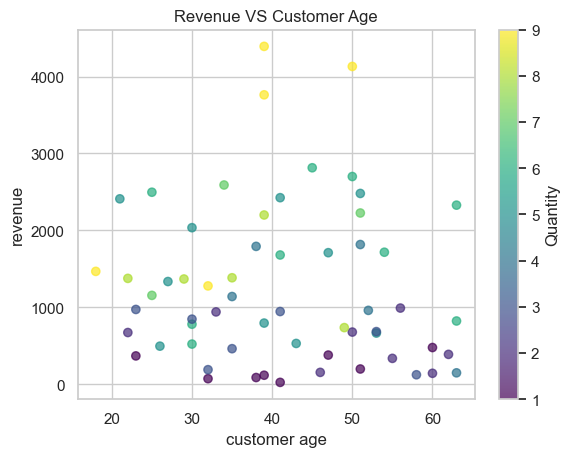

In [3]:
## Scatter plot
## plt.scatter(x , y , s=none , c=none , alpha= ,cmap=)
## x, y --> 2 numeric columns
## s --> marker size [ single number / array]
## c --> marker color
## alpha --> 0 to 1
plt.scatter(df['CustomerAge'] , df['Revenue']  , alpha= 0.7 , c=df["Quantity"], cmap="viridis")
plt.xlabel('customer age')
plt.ylabel('revenue')
plt.colorbar(label='Quantity')
plt.title('Revenue VS Customer Age')
plt.show()

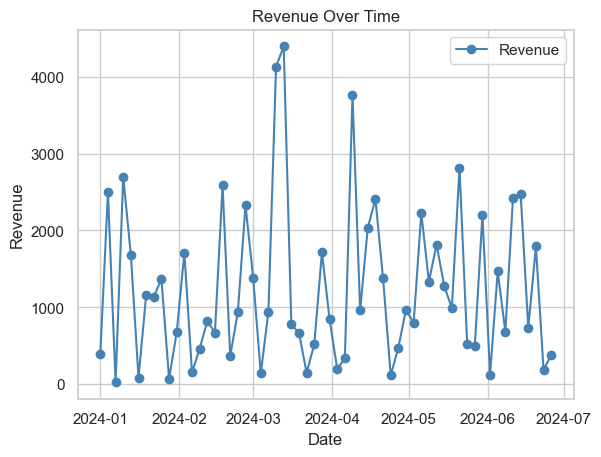

In [4]:
## line chart
# plt.plot(x , y , marker= , linestyle=, color=)
# marker --> shape drawn at each data point
daily_revenue = df.groupby('OrderDate')['Revenue'].sum()

plt.plot(daily_revenue.index , daily_revenue.values , marker='o', linestyle='-' , color='steelblue', label='Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.title('Revenue Over Time')
plt.legend()
plt.show()

In [5]:
daily_revenue

OrderDate
2024-01-01     388
2024-01-04    2496
2024-01-07      24
2024-01-10    2700
2024-01-13    1680
2024-01-16      87
2024-01-19    1155
2024-01-22    1140
2024-01-25    1368
2024-01-28      72
2024-01-31     678
2024-02-03    1710
2024-02-06     154
2024-02-09     462
2024-02-12     822
2024-02-15     672
2024-02-18    2590
2024-02-21     368
2024-02-24     940
2024-02-27    2328
2024-03-01    1384
2024-03-04     142
2024-03-07     945
2024-03-10    4131
2024-03-13    4392
2024-03-16     780
2024-03-19     665
2024-03-22     148
2024-03-25     522
2024-03-28    1716
2024-03-31     846
2024-04-03     198
2024-04-06     336
2024-04-09    3762
2024-04-12     960
2024-04-15    2035
2024-04-18    2410
2024-04-21    1376
2024-04-24     117
2024-04-27     477
2024-04-30     972
2024-05-03     795
2024-05-06    2226
2024-05-09    1335
2024-05-12    1816
2024-05-15    1278
2024-05-18     990
2024-05-21    2814
2024-05-24     530
2024-05-27     495
2024-05-30    2200
2024-06-02     123
20

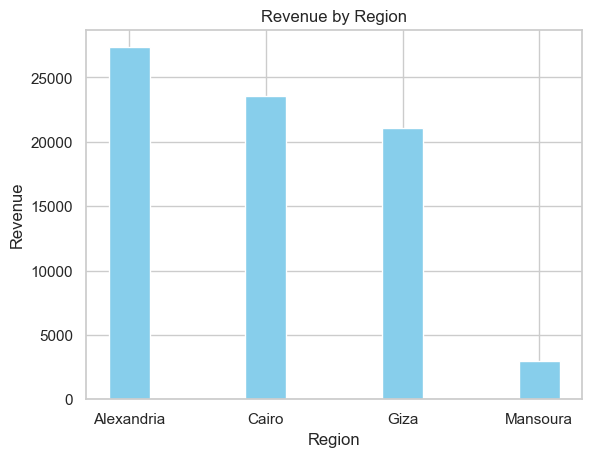

In [6]:
# Bar chart
## plt.bar(x , height , width=[0:1] , color=)
revenue_by_region = df.groupby('Region')['Revenue'].sum()

plt.bar(revenue_by_region.index, revenue_by_region.values , color='skyblue' , width=0.3)
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.title('Revenue by Region')
plt.show()

In [7]:
revenue_by_region.values

array([27349, 23543, 21070,  2940])

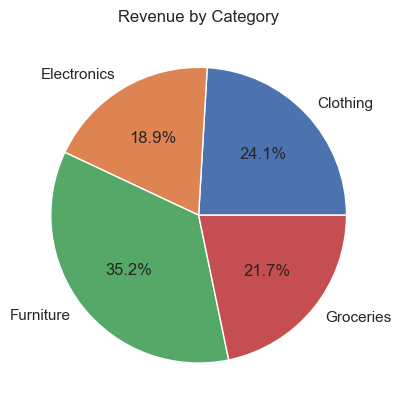

In [8]:
## pie chart
# plt.pie(x , labels= , autopct=)
revenue_by_category = df.groupby('Category')['Revenue'].sum()

plt.pie(revenue_by_category.values, labels = revenue_by_category.index, autopct="%1.1f%%" )
plt.title('Revenue by Category')
plt.show()


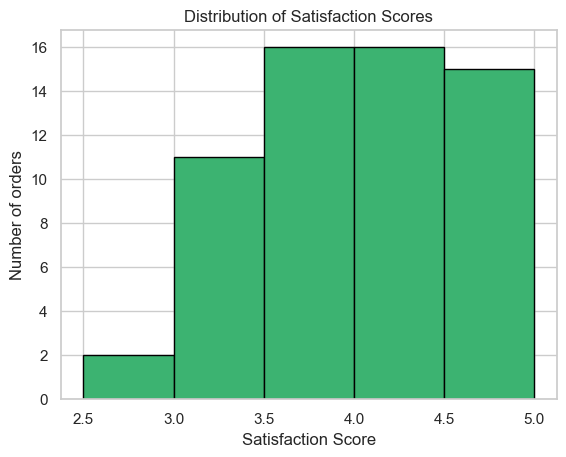

In [9]:
# Histogram
# plt.hist(x , bins= , color= , edgecolor = )

plt.hist(df['SatisfactionScore'], bins=5, color='mediumseagreen' , edgecolor = 'black')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of orders')
plt.title('Distribution of Satisfaction Scores')
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_10208\497576702.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups , labels=df['Category'].unique(), vert=False )


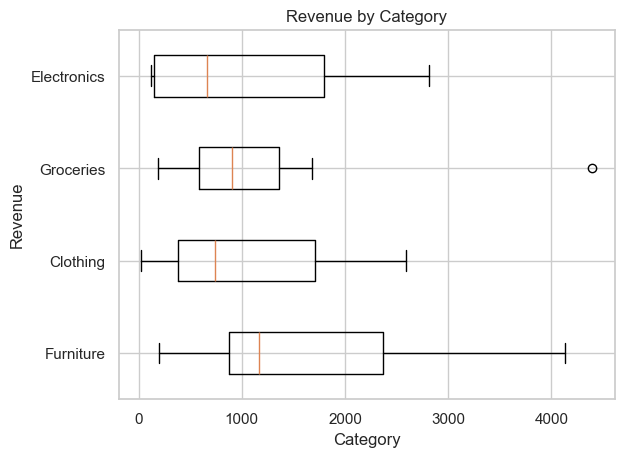

In [10]:
## box plot
# plt.boxplot(x , vert= True, lables=)
groups = [ df.loc[df['Category'] == cat , 'Revenue']   for cat in df['Category'].unique()  ]

plt.boxplot(groups , labels=df['Category'].unique(), vert=False )
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Category')
plt.show()

In [11]:
groups

[0      388
 3     2700
 15     672
 18     940
 19    2328
 22     945
 23    4131
 31     198
 33    3762
 34     960
 42    2226
 43    1335
 44    1816
 46     990
 48     530
 55    2480
 Name: Revenue, dtype: int64,
 1     2496
 2       24
 5       87
 8     1368
 9       72
 10     678
 11    1710
 13     462
 16    2590
 35    2035
 37    1376
 38     117
 41     795
 53     684
 54    2425
 56     736
 59     379
 Name: Revenue, dtype: int64,
 4     1680
 7     1140
 14     822
 20    1384
 24    4392
 25     780
 28     522
 30     846
 32     336
 39     477
 40     972
 45    1278
 52    1467
 58     189
 Name: Revenue, dtype: int64,
 6     1155
 12     154
 17     368
 21     142
 26     665
 27     148
 29    1716
 36    2410
 47    2814
 49     495
 50    2200
 51     123
 57    1792
 Name: Revenue, dtype: int64]

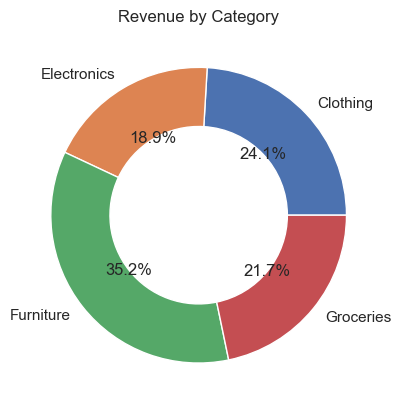

In [12]:
plt.pie(revenue_by_category.values, labels= revenue_by_category.index ,autopct='%1.1f%%' , wedgeprops=dict(width=0.4))
plt.title('Revenue by Category')
plt.show()

## Seaborn

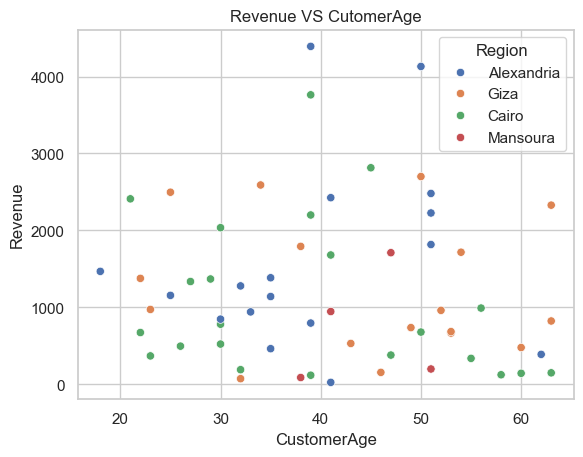

In [13]:
# scatter plot
# sns.scatterplot(df , x= "columnName" , y="columnName" ,hue=)
sns.scatterplot(data=df , x="CustomerAge" , y="Revenue" , hue="Region")
plt.title('Revenue VS CutomerAge')
plt.show()

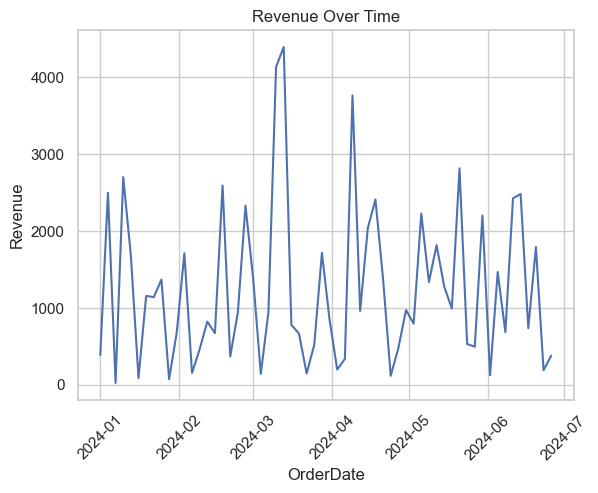

In [14]:
# line chart
# sns.lineplot(data , x, y , hue )
daily = df.groupby('OrderDate', as_index=False)['Revenue'].sum()
sns.lineplot(data = daily , x='OrderDate' , y='Revenue')
plt.title('Revenue Over Time')
plt.xticks(rotation=45)
plt.show()

In [15]:
daily

,OrderDate,Revenue
0,2024-01-01,388
1,2024-01-04,2496
2,2024-01-07,24
3,2024-01-10,2700
4,2024-01-13,1680
5,2024-01-16,87
6,2024-01-19,1155
7,2024-01-22,1140
8,2024-01-25,1368
9,2024-01-28,72


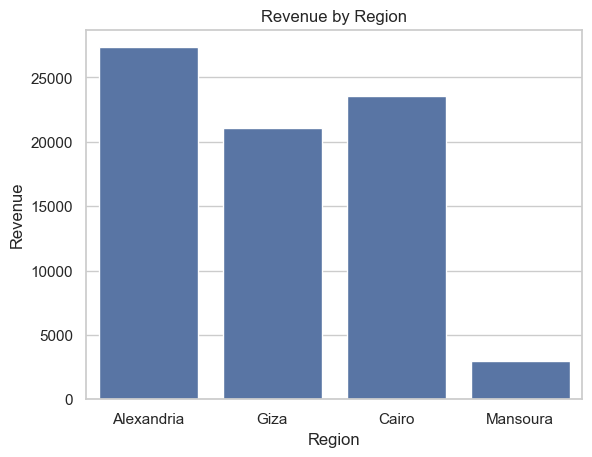

In [16]:
# bar chart
# sns.barplot(data , x, y , estimator='')
sns.barplot(data=df , x='Region' , y = 'Revenue' , estimator='sum', errorbar=None)
plt.title('Revenue by Region')
plt.show()

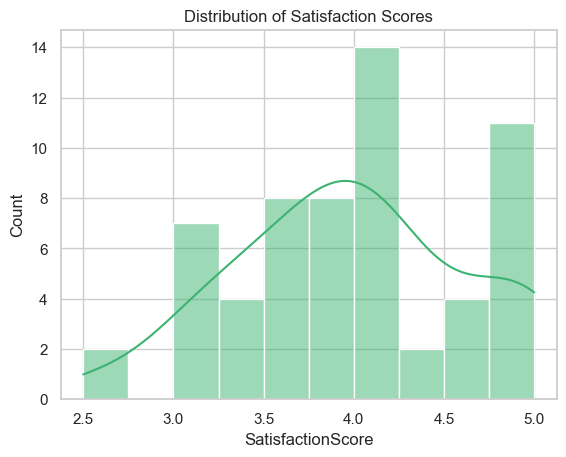

In [17]:
# Histogram
# sns.histplot(data , x , bins= , kde , hue=)
sns.histplot(data=df, x='SatisfactionScore', bins=10, kde=True ,color= 'mediumseagreen')
plt.title('Distribution of Satisfaction Scores')
plt.show()

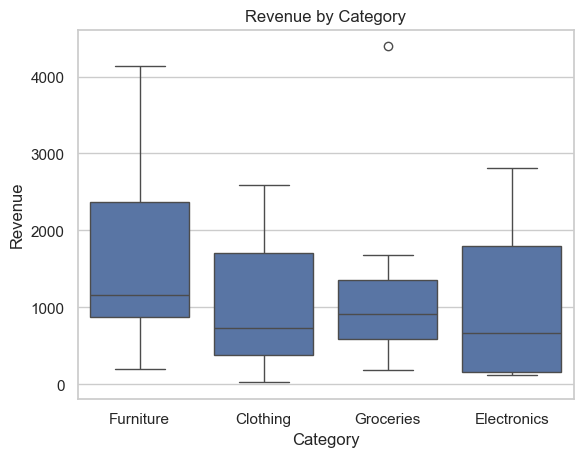

In [18]:
sns.boxplot(data=df, x='Category' , y='Revenue')
plt.title('Revenue by Category')
plt.show()

## Plotly (plotly.Express)

In [19]:
# scatter plot
# px.scatter(df , x , y ,color , title= , hover_data , size=)
fig = px.scatter(df, x='CustomerAge', y='Revenue', color='Region',title='Revenue VS CustomerAge', hover_data=['Category'], size='Quantity')
fig.show()

In [20]:
daily.head()

,OrderDate,Revenue
0,2024-01-01,388
1,2024-01-04,2496
2,2024-01-07,24
3,2024-01-10,2700
4,2024-01-13,1680


In [21]:
fig = px.line(daily , x='OrderDate' , y='Revenue' , title='Revenue Over Time', markers = True)
fig.show()

In [22]:
revenue_by_reg_cat = df.groupby(['Region', 'Category'], as_index=False)['Revenue'].sum()
fig = px.bar(revenue_by_reg_cat, x='Region' , y='Revenue', color='Category', title='Revenue by Region and Category' , barmode='group')
fig.show()

In [23]:
## boxplot
#points --> "Outlier" / "all"
fig = px.box(df,x='Category' , y='Revenue', points='outliers' , title='Revenue by Category')
fig.show()

In [24]:
fig = px.pie(revenue_by_category, values='Revenue', names=revenue_by_category.index, title='Revenue by Category', hole=0.7)
fig.show()